# Tutorials

## Step 1: Download the Demo Data

In [ ]:
! wget https://raw.githubusercontent.com/JiahaoChow/midas_pl/refs/heads/master/demo_data/teadog_mosaic_8k.zip
! unzip teadog_full_8k.zip

## Step 2: Set Up the Environment

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

from scmidas.model import MIDAS
from scmidas.utils import load_predicted
import lightning as L
from lightning.pytorch import loggers as pl_loggers

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sc.set_figure_params(figsize=(4, 4))

## Step 3: Configure the Model

In [2]:
task = "teadog_mosaic_8k"
transfrom = {"atac":"binarize"}
model = MIDAS.configure_data_from_dir(task, transfrom, config_name="default")

Input Summary (Mask Density and Number)
              RNA       ADT ATAC  #Cell
BATCH 0         -  0.211268    1   1000
BATCH 1  0.820855         -    1   1000
BATCH 2  0.954287  0.976526    -   1000
BATCH 3  0.926859         -    -   1000
The model is initialized with the configurations from '/opt/data/private/zjh/code/midas_pl/scmidas/model_config.toml' [default].
Modify this file to change the configurations.


## Step 4: Train the Model
~2h

In [ ]:
tb_logger = pl_loggers.TensorBoardLogger(save_dir="./logs/", version=task)
trainer = L.Trainer(
    accelerator="auto",
    devices=1,
    precision=32,
    strategy="auto",
    num_nodes=1,
    max_epochs = 2000,
    logger=tb_logger,
    log_every_n_steps= 5)
trainer.fit(model=model)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type          | Params | Mode 
-----------------------------------------------
0 | net  | VAE           | 49.8 M | train
1 | dsc  | Discriminator | 52.2 K | train
-----------------------------------------------
49.8 M    Trainable params
0         Non-trainable params
49.8 M    Total params
199.356   Total estimated model params size (MB)
676       Modules in train mode
0         Modules in eval mode


Total number of samples: 4000 from 4 datasets.
Using MultiBatchSampler for data loading.
DataLoader created with batch size 256 and 20 workers.


/root/anaconda3/envs/pl/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Epoch 500: 100%|██████████| 16/16 [00:04<00:00,  3.96it/s, v_num=c_8k, loss_/recon_loss_step=2.26e+3, loss_/kld_loss_step=91.20, loss_/consistency_loss_step=0.000, loss/net_step=2.28e+3, loss/dsc_step=69.50, loss_/recon_loss_epoch=6.28e+3, loss_/kld_loss_epoch=104.0, loss_/consistency_loss_epoch=26.60, loss/net_epoch=6.33e+3, loss/dsc_epoch=78.40]Checkpoint successfully saved to './saved_models/model_epoch500_20241209-031324.pt'.
Checkpoint saved for epoch 500 at './saved_models/model_epoch500_20241209-031324.pt'.
Epoch 1000: 100%|██████████| 16/16 [00:03<00:00,  4.61it/s, v_num=c_8k, loss_/recon_loss_step=9.09e+3, loss_/kld_loss_step=113.0, loss_/consistency_loss_step=20.10, loss/net_step=9.14e+3, loss/dsc_step=87.40, loss_/recon_loss_epoch=5.96e+3, loss_/kld_loss_epoch=110.0, loss_/consistency_loss_epoch=21.30, loss/net_epoch=6.02e+3, loss/dsc_epoch=79.10]Checkpoint successfully saved to './saved_models/model_epoch1000_20241209-034519.pt'.
Checkpoint saved for epoch 1000 at './saved_

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 1999: 100%|██████████| 16/16 [00:03<00:00,  4.14it/s, v_num=c_8k, loss_/recon_loss_step=2.75e+3, loss_/kld_loss_step=115.0, loss_/consistency_loss_step=33.00, loss/net_step=2.82e+3, loss/dsc_step=86.70, loss_/recon_loss_epoch=5.58e+3, loss_/kld_loss_epoch=113.0, loss_/consistency_loss_epoch=21.50, loss/net_epoch=5.64e+3, loss/dsc_epoch=78.50]
Checkpoint successfully saved to './saved_models/model_epoch2000_20241209-044721.pt'.
Checkpoint saved for epoch 2000 at './saved_models/model_epoch2000_20241209-044721.pt'.


## Step 5: Inference

In [4]:
model.predict("./predict/"+task,         
        joint_latent=True,
        mod_latent=True,
        impute=True,
        batch_correct=True,
        translate=True,
        input=True)

Predicting ...
Processing batch 0: ['atac', 'adt']


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [02:27<00:00, 36.91s/it]


Processing batch 1: ['atac', 'rna']


100%|██████████| 4/4 [02:25<00:00, 36.36s/it]


...

100%|██████████| 4/4 [00:11<00:00,  2.86s/it]


Processing batch 2: ['rna', 'adt']


100%|██████████| 4/4 [00:05<00:00,  1.27s/it]


Processing batch 3: ['rna']


100%|██████████| 4/4 [00:04<00:00,  1.15s/it]


## Step 6: Outputs of MIDAS

### load labels

In [4]:
label = []
for i in ["w1", "w6", "lll_ctrl", "dig_stim"]:
    label.append(pd.read_csv("/opt/data/private/zjh/code/midas_pl/teadog_8k_label/%s.csv"%i, index_col=0).values.flatten()[:1000])
label = np.concatenate(label)

### joint embeddings (biological information c and technical information u)

Loading predicted variables ...
Loading batch 0: z, joint


100%|██████████| 4/4 [00:00<00:00, 218.18it/s]


Loading batch 1: z, joint


100%|██████████| 4/4 [00:00<00:00, 254.01it/s]


Loading batch 2: z, joint


100%|██████████| 4/4 [00:00<00:00, 199.11it/s]


Loading batch 3: z, joint


100%|██████████| 4/4 [00:00<00:00, 230.32it/s]

Converting to numpy ...
Converting batch 0: s, joint
Converting batch 0: z, joint
Converting batch 1: s, joint
Converting batch 1: z, joint
Converting batch 2: s, joint
Converting batch 2: z, joint
Converting batch 3: s, joint
Converting batch 3: z, joint



/root/anaconda3/envs/pl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


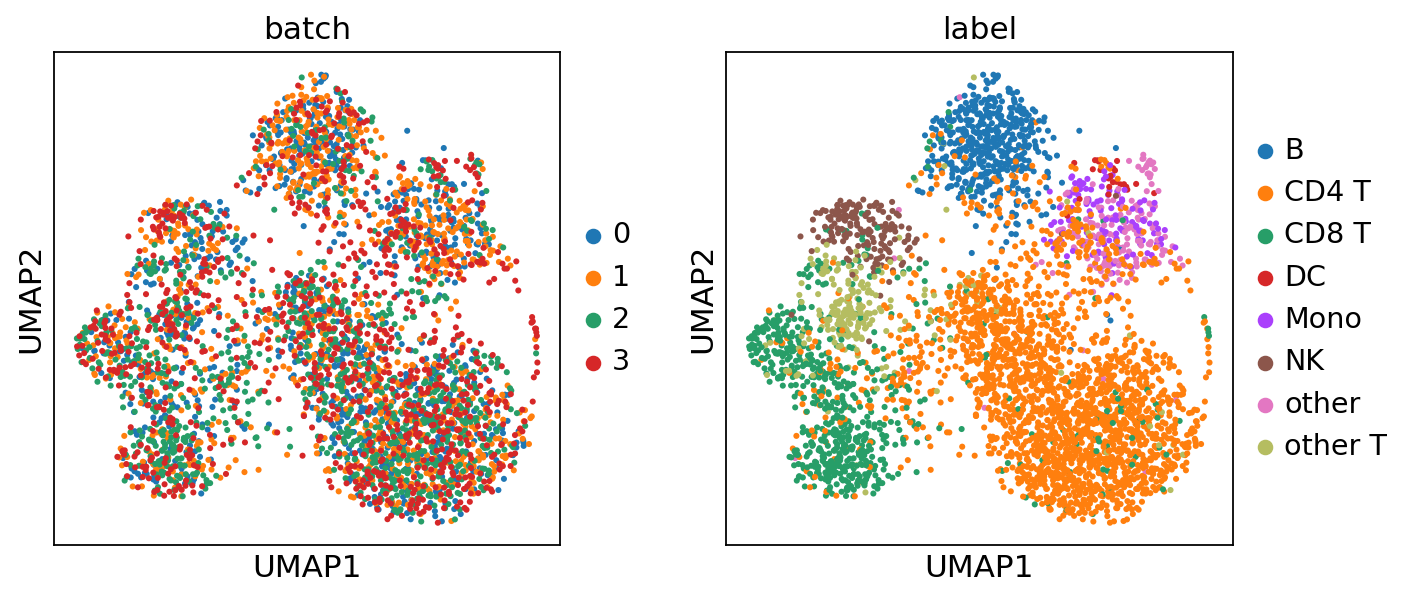

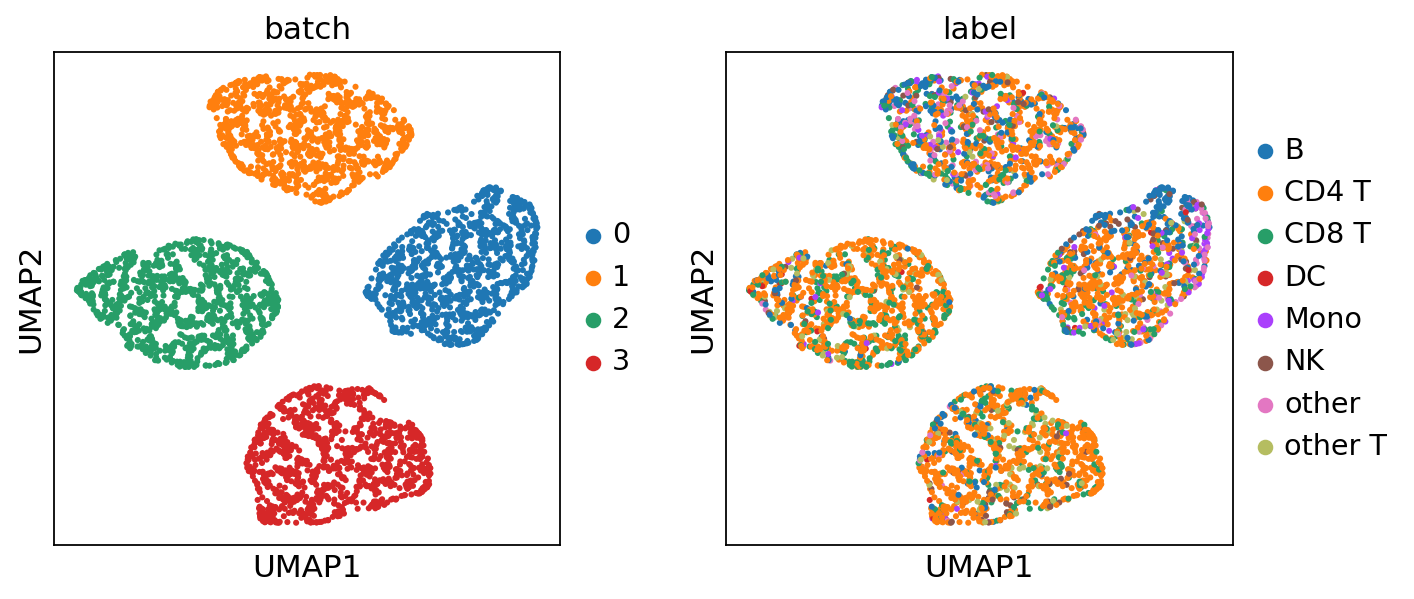

In [7]:
#check the batch effect of raw counts (RNA)
joint_embeddings = load_predicted("./predict/"+task, model.s_joint, model.combs, model.mods, joint_latent=True)

adata_bio = sc.AnnData(joint_embeddings["z"]["joint"][:, :model.dim_c])
adata_tech = sc.AnnData(joint_embeddings["z"]["joint"][:, model.dim_c:])

adata_bio.obs["batch"] = joint_embeddings["s"]["joint"].astype("int").astype("str")
adata_bio.obs["label"] = label
adata_tech.obs["batch"] = joint_embeddings["s"]["joint"].astype("int").astype("str")
adata_tech.obs["label"] = label

for adata in [adata_bio, adata_tech]:
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.pl.umap(adata, color=["batch", "label"], ncols=2)

Loading predicted data from: ./predict/teadog_mosaic_8k
Loading predicted variables ...
Loading batch 0: z, joint


100%|██████████| 4/4 [00:00<00:00, 169.67it/s]


Loading batch 1: z, joint


100%|██████████| 4/4 [00:00<00:00, 172.17it/s]


Loading batch 2: z, joint


100%|██████████| 4/4 [00:00<00:00, 160.72it/s]


Loading batch 3: z, joint


100%|██████████| 4/4 [00:00<00:00, 165.16it/s]

Converting to numpy ...
Converting batch 0: s, joint
Converting batch 0: z, joint
Converting batch 1: s, joint
Converting batch 1: z, joint
Converting batch 2: s, joint
Converting batch 2: z, joint
Converting batch 3: s, joint
Converting batch 3: z, joint


Processing biological embedding...
 - Computing neighbors...
 - Computing UMAP...
 - Generating UMAP plot for biological_embedding.png...
 - UMAP plot saved to: ./figs/biological_embedding.png
Processing technical embedding...
 - Computing neighbors...
 - Computing UMAP...
 - Generating UMAP plot for technical_embedding.png...
 - UMAP plot saved to: ./figs/technical_embedding.png
UMAP generation completed.


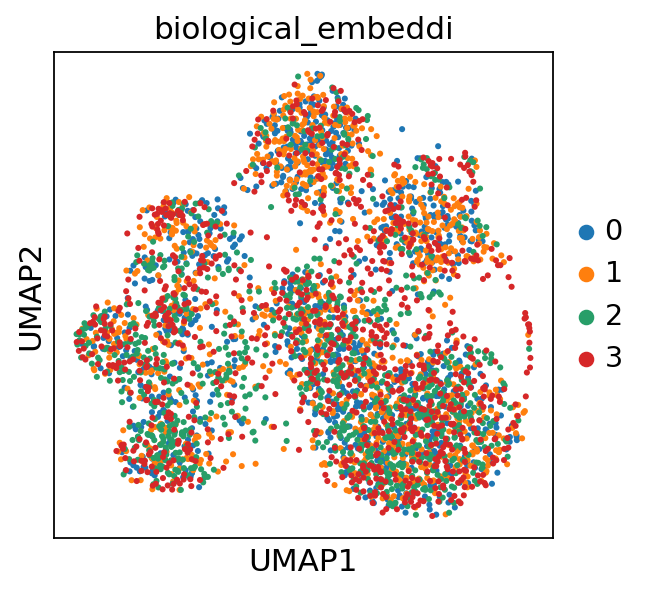

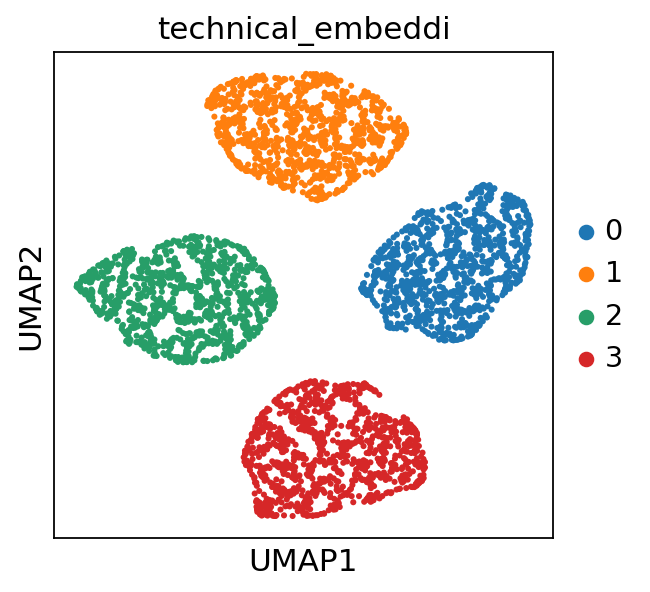

In [8]:
#the same as the upper box, here we provide a api for quick visualization of the joint embeddings
adata, _ = model.get_emb_umap("./predict/"+task)

### modality-specific embeddings

In [56]:
adata_mod_concat.obs['batch'].dtypes

dtype('O')

In [62]:
#check the batch effect of raw counts (RNA)
mod_embeddings = load_predicted("./predict/"+task, model.s_joint, model.combs, model.mods, mod_latent=True, group_by="batch")
adata_list = []
for i in range(model.dims_s["joint"]):
    for m in model.mods+["joint"]:
        if m in mod_embeddings[i]["z"]:
            adata = sc.AnnData(mod_embeddings[i]["z"][m][:, :model.dim_c])
            adata.obs["batch"] = "BATCH "+str(i)
            adata.obs["modality"] = m
            adata.obs["label"] = label[(i*1000):((i+1)*1000)]
            adata_list.append(adata)
adata_mod_concat = sc.concat(adata_list)
for i in adata_mod_concat.obs:
    adata_mod_concat.obs[i] = adata_mod_concat.obs[i].astype('category')
sc.pp.neighbors(adata_mod_concat)
sc.tl.umap(adata_mod_concat)

Loading predicted variables ...
Loading batch 0: z, joint


100%|██████████| 4/4 [00:00<00:00, 140.83it/s]


Loading batch 0: z, atac


100%|██████████| 4/4 [00:00<00:00, 164.54it/s]


Loading batch 0: z, adt


...

100%|██████████| 4/4 [00:00<00:00,  6.51it/s]


Loading batch 3: z, rna


100%|██████████| 4/4 [00:00<00:00, 158.77it/s]


Converting to numpy ...
Converting batch 0: s, joint
Converting batch 0: s, atac
Converting batch 0: s, adt
Converting batch 0: z, joint
Converting batch 0: z, atac
Converting batch 0: z, adt
Converting batch 1: s, joint
Converting batch 1: s, atac
Converting batch 1: s, rna
Converting batch 1: z, joint
Converting batch 1: z, atac
Converting batch 1: z, rna
Converting batch 2: s, joint
Converting batch 2: s, rna
Converting batch 2: s, adt
Converting batch 2: z, joint
Converting batch 2: z, rna
Converting batch 2: z, adt
Converting batch 3: s, joint
Converting batch 3: s, rna
Converting batch 3: z, joint
Converting batch 3: z, rna


/root/anaconda3/envs/pl/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


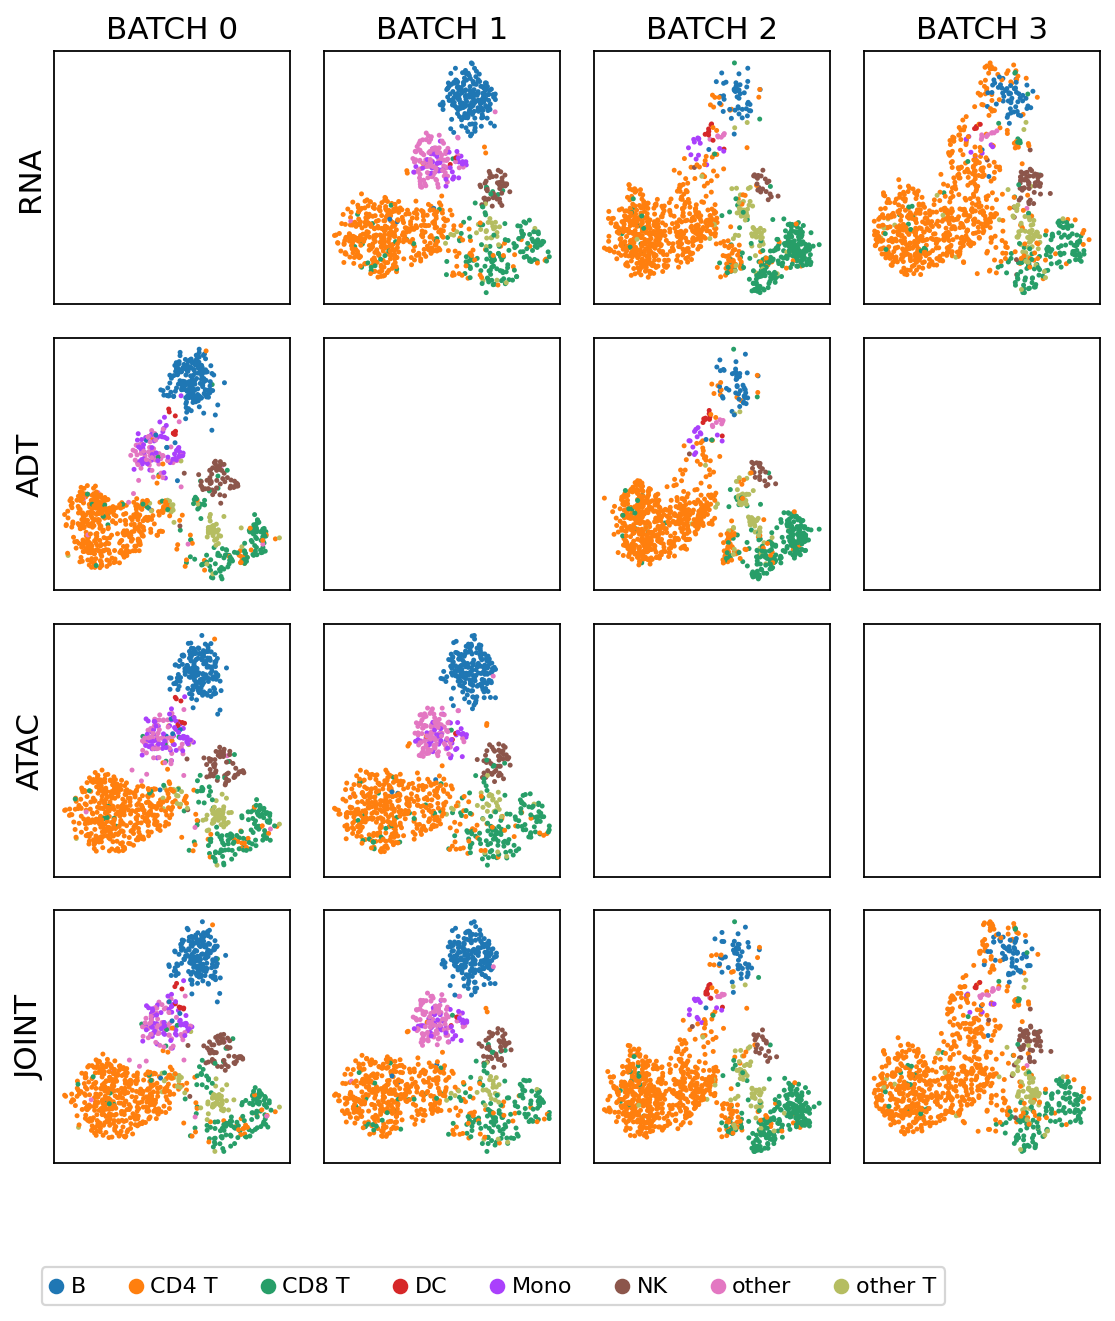

In [64]:
# setup figure
nrows = len(model.mods) + 1
ncols = model.dims_s["joint"]
point_size = 20

fig, ax = plt.subplots(nrows, ncols, figsize=[2 * ncols, 2 * nrows])

# set up the name of modalities and batch
mod_names = model.mods + ["joint"]
batch_names = [f"Batch {b}" for b in range(model.dims_s["joint"])]

# iteratively scatter the data
for i, mod in enumerate(mod_names):
    for b in range(model.dims_s["joint"]):
        # filter data
        adata = adata_mod_concat[
            (adata_mod_concat.obs["modality"] == mod) & 
            (adata_mod_concat.obs["batch"] == "BATCH "+str(b))
        ].copy()
        if len(adata):
            sc.pl.umap(adata, color="label", show=False, ax=ax[i, b], s=point_size)
            ax[i, b].get_legend().set_visible(False)
            handles, labels = ax[i, b].get_legend_handles_labels()
        ax[i, b].set_xticks([])
        ax[i, b].set_yticks([])
        ax[i, b].set_xlabel("")
        if b==0:
            ax[i, b].set_ylabel(mod.upper())
        else:
            ax[i, b].set_ylabel("")
        if i==0:
            ax[i, b].set_title("BATCH "+str(b))
        else:
            ax[i, b].set_title("")
# create global legend
fig.legend(handles, labels, loc="center", bbox_to_anchor=(0.5, -0.02), ncol=len(labels), fontsize=10)

# adjust the figure
plt.tight_layout(rect=[0.1, 0.05, 1, 1])
plt.show()

### inputs

Loading predicted variables ...
Loading batch 0: z, joint


100%|██████████| 4/4 [00:00<00:00, 169.50it/s]


Loading batch 0: x, atac


100%|██████████| 4/4 [00:02<00:00,  1.38it/s]


Loading batch 0: x, adt


...

100%|██████████| 4/4 [00:00<00:00, 148.74it/s]


Loading batch 3: x, rna


100%|██████████| 4/4 [00:00<00:00,  9.04it/s]


Converting to numpy ...
Converting batch 0: s, joint
Converting batch 0: z, joint
Converting batch 0: x, atac
Converting batch 0: x, adt
Converting batch 1: s, joint
Converting batch 1: z, joint
Converting batch 1: x, atac
Converting batch 1: x, rna
Converting batch 2: s, joint
Converting batch 2: z, joint
Converting batch 2: x, rna
Converting batch 2: x, adt
Converting batch 3: s, joint
Converting batch 3: z, joint
Converting batch 3: x, rna


/root/anaconda3/envs/pl/lib/python3.12/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 4047 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


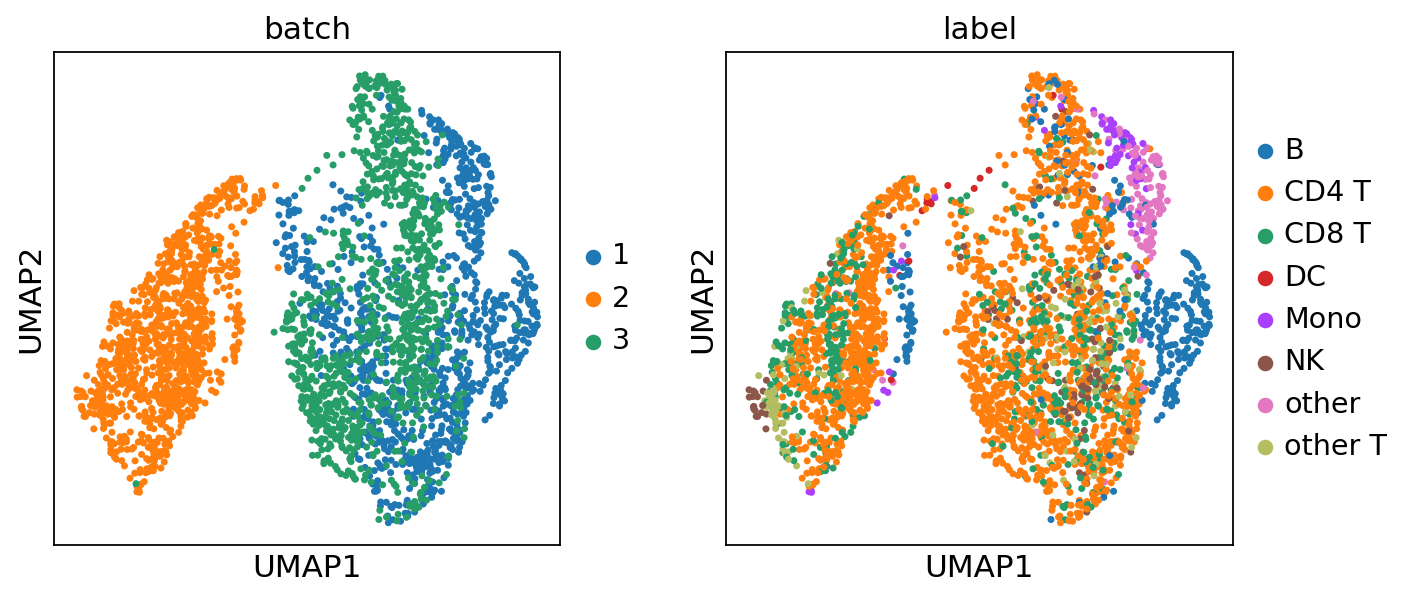

In [33]:
#check the batch effect of raw counts (RNA)
raw_data = load_predicted("./predict/"+task, model.s_joint, model.combs, model.mods, input=True)
raw_data_adata = sc.AnnData(raw_data["x"]["rna"])
raw_data_adata.obs["batch"] = raw_data["s"]["joint"].astype("int").astype("str")[1000:]
raw_data_adata.obs["label"] = label[1000:]
raw_data_adata
sc.pp.neighbors(raw_data_adata)
sc.tl.umap(raw_data_adata)
sc.pl.umap(raw_data_adata, color=["batch", "label"], ncols=2)

### batch-corrected counts

Loading predicted variables ...
Loading batch 0: z, joint


100%|██████████| 4/4 [00:00<00:00, 11.60it/s]


Loading batch 0: x_bc, rna


100%|██████████| 4/4 [00:00<00:00, 13.47it/s]


Loading batch 0: x_bc, adt


...

100%|██████████| 4/4 [00:00<00:00, 97.94it/s]


Loading batch 3: x_bc, atac


100%|██████████| 4/4 [00:00<00:00,  4.16it/s]


Converting to numpy ...
Converting batch 0: s, joint
Converting batch 0: z, joint
Converting batch 0: x_bc, rna
Converting batch 0: x_bc, adt
Converting batch 0: x_bc, atac
Converting batch 1: s, joint
Converting batch 1: z, joint
Converting batch 1: x_bc, rna
Converting batch 1: x_bc, adt
Converting batch 1: x_bc, atac
Converting batch 2: s, joint
Converting batch 2: z, joint
Converting batch 2: x_bc, rna
Converting batch 2: x_bc, adt
Converting batch 2: x_bc, atac
Converting batch 3: s, joint
Converting batch 3: z, joint
Converting batch 3: x_bc, rna
Converting batch 3: x_bc, adt
Converting batch 3: x_bc, atac


/root/anaconda3/envs/pl/lib/python3.12/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 4047 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


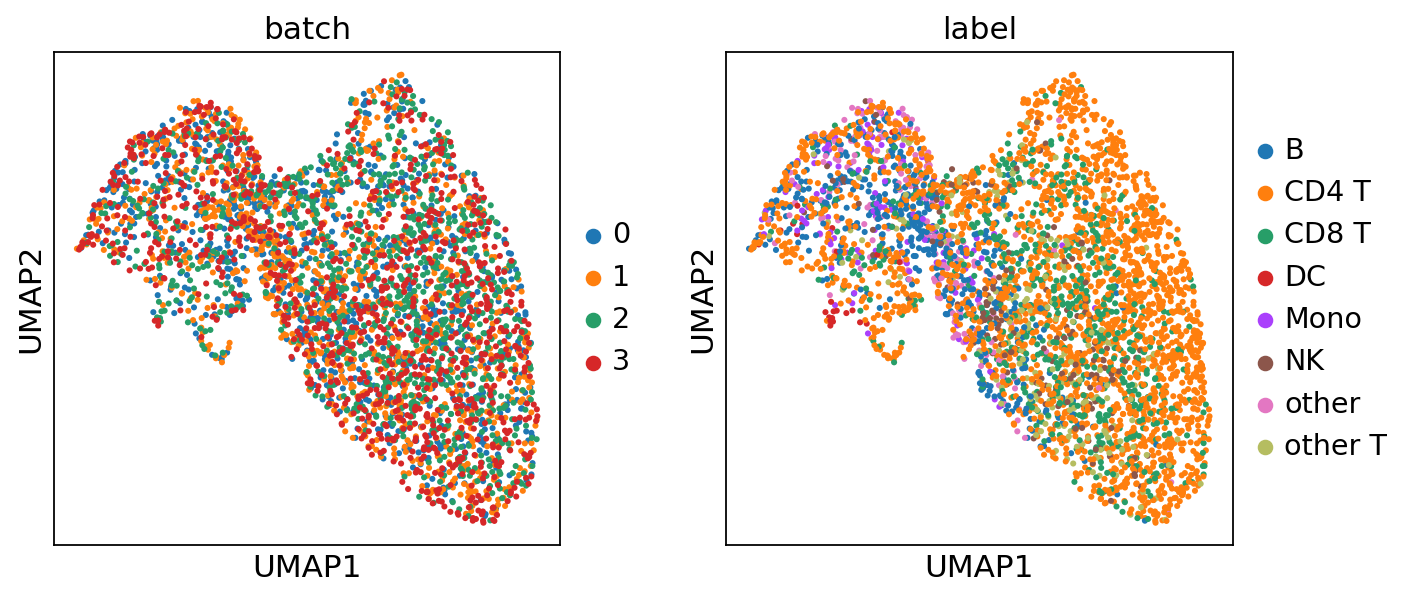

In [36]:
#check the batch effect of MIDAS's batch-corrected counts (RNA)
batch_corrected = load_predicted("./predict/"+task, model.s_joint, model.combs, model.mods, batch_correct=True)
batch_corrected_adata = sc.AnnData(batch_corrected["x_bc"]["rna"])
batch_corrected_adata.obs["batch"] = batch_corrected["s"]["joint"].astype("int").astype("str")
batch_corrected_adata.obs["label"] = label
batch_corrected_adata
sc.pp.neighbors(batch_corrected_adata)
sc.tl.umap(batch_corrected_adata)
sc.pl.umap(batch_corrected_adata, color=["batch", "label"], ncols=2)

### imputed counts

In [38]:
imputed = load_predicted("./predict/"+task, model.s_joint, model.combs, model.mods, impute=True)

Loading predicted variables ...
Loading batch 0: z, joint


100%|██████████| 4/4 [00:00<00:00, 194.35it/s]


Loading batch 0: x_impt, rna


100%|██████████| 4/4 [00:01<00:00,  3.68it/s]


Loading batch 0: x_impt, adt


...

Loading batch 3: x_impt, adt


100%|██████████| 4/4 [00:00<00:00, 64.93it/s]


Loading batch 3: x_impt, atac


100%|██████████| 4/4 [00:05<00:00,  1.46s/it]


Converting to numpy ...
Converting batch 0: s, joint
Converting batch 0: z, joint
Converting batch 0: x_impt, rna
Converting batch 0: x_impt, adt
Converting batch 0: x_impt, atac
Converting batch 1: s, joint
Converting batch 1: z, joint
Converting batch 1: x_impt, rna
Converting batch 1: x_impt, adt
Converting batch 1: x_impt, atac
Converting batch 2: s, joint
Converting batch 2: z, joint
Converting batch 2: x_impt, rna
Converting batch 2: x_impt, adt
Converting batch 2: x_impt, atac
Converting batch 3: s, joint
Converting batch 3: z, joint
Converting batch 3: x_impt, rna
Converting batch 3: x_impt, adt
Converting batch 3: x_impt, atac


(Optional) calculate the re

In [2]:
import pandas as pd

In [ ]:
ref_adt = pd.read_csv("/opt/data/private/zjh/code/midas_pl/teadog_full_8k/batch_1/mat/adt.csv", index_col=0).iloc[:1000]

In [6]:
ref_adt.to_csv("./ref_adt.csv")

In [ ]:
ref_adt = pd.read_csv("./teadog_full_8k/ref_adt.csv", index_col=0).values

In [49]:
pearsonr(ref_adt.reshape(-1), imputed["x_impt"]["adt"][1000:2000].reshape(-1))[0]

0.5376321021516293